<a href="https://colab.research.google.com/github/imperorrp/discrete-generative-models-proj-1/blob/main/notebooks/tc_lora_cifar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TC-LoRA on CIFAR-100 images

Baseline 1 of 3. Trains a base diffusion model, freezes it, trains a TC-LoRA
hypernetwork on top, samples from both.

**Paper:** Cho, Ohana, Jacobsen, Jothi, Chen, Mao, Can.
*TC-LoRA: Temporally Modulated Conditional LoRA for Adaptive Diffusion Control.*
NeurIPS 2025 SpaVLE workshop. [arXiv:2510.09561](https://arxiv.org/abs/2510.09561)

**The authors released no code** (checked 2026-09-28). `src/guidance/baselines/tc_lora.py`
is our reimplementation from Eq. 1 and Appendices A-B; its header lists every deviation.
Report this as a reimplementation, not as their result reproduced.

Run top to bottom. On Colab set **Runtime > Change runtime type > GPU** first.

In [1]:
# Colab bootstrap. Run once.
import importlib.util, subprocess, sys, os

for pkg in ("transformers", "datasets"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

if importlib.util.find_spec("guidance") is None:
    if not os.path.exists("discrete-generative-models-proj-1"):
        subprocess.run(["git", "clone", "-q",
                        "https://github.com/imperorrp/discrete-generative-models-proj-1.git"],
                       check=True)
    sys.path.insert(0, "discrete-generative-models-proj-1/src")

import torch
from guidance.baselines.tc_lora import TCLoRA
print("device:", "cuda" if torch.cuda.is_available()
      else "CPU  <-- Runtime > Change runtime type > GPU")

device: cuda


## Data source

You do not need to do anything here. The loader tries, in order:

1. a local copy -- `./cifar`, `/content/cifar`, `/content/drive/MyDrive/cifar`, and a few
   others, each expected to contain a `cifar-100-python` folder
2. the **HuggingFace CDN**, which takes seconds

It never touches `www.cs.toronto.edu/~kriz/`, torchvision's default, which is
rate-limited to roughly 50 kB/s and takes most of an hour for 169 MB.

If you do want to use a Drive copy, mount Drive with the **folder icon in the left
sidebar, then the Mount Drive button**. Calling `drive.mount()` from a code cell often
fails with `MessageError` when the browser blocks third-party cookies; the sidebar button
handles the auth flow properly.

## Config

In [2]:
import math, time, json
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

@dataclass
class Cfg:
    seed: int = 10
    batch_size: int = 64
    base_epochs: int = 30
    lora_epochs: int = 15
    lr_base: float = 2e-4
    lr_hyper: float = 1e-4
    K: int = 1000                  # diffusion training steps
    sample_steps: int = 50         # DDIM steps
    rank: int = 4
    hyper_width: int = 256
    limit: int = 0                 # >0 truncates the training set, for smoke tests

cfg = Cfg()
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(cfg.seed); np.random.seed(cfg.seed)
print(DEV, asdict(cfg))

cuda {'seed': 10, 'batch_size': 64, 'base_epochs': 30, 'lora_epochs': 15, 'lr_base': 0.0002, 'lr_hyper': 0.0001, 'K': 1000, 'sample_steps': 50, 'rank': 4, 'hyper_width': 256, 'limit': 0}


## Data

From `src/guidance/data/cifar.py`. Pixels normalised to `[-1, 1]`; 50 images per class
held out for validation with a seeded per-class shuffle, so both splits see all 100
classes.

In [3]:
from guidance.data.cifar import make_loaders

train_loader, val_loader, meta = make_loaders(
    batch_size=cfg.batch_size, seed=cfg.seed, limit=cfg.limit)

xb, cb = next(iter(train_loader))
print("x", tuple(xb.shape), f"[{float(xb.min()):.2f}, {float(xb.max()):.2f}]",
      "| cond", tuple(cb.shape))
print("train batches", len(train_loader), "| val batches", len(val_loader))
print("conditions", meta["n_conditions"], "| example text:", meta["cond_text"][0])

no local copy found; fetching from the HuggingFace CDN


README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  119MB            

cifar100/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

cifar100/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.8MB            

cifar100/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

x (64, 3, 32, 32) [-1.00, 1.00] | cond (64,)
train batches 703 | val batches 79
conditions 100 | example text: a photo of a apple


## Frozen condition encoder

`h(c)` is a frozen CLIP text embedding of the condition description. Falls back to fixed
random vectors if CLIP will not load, so the notebook still runs — but a fallback run is
**not a result**, and the manifest records it.

In [4]:
def build_cond_embeddings(texts, device):
    try:
        from transformers import CLIPTokenizer, CLIPTextModel
        name = "openai/clip-vit-base-patch32"
        tok = CLIPTokenizer.from_pretrained(name)
        enc = CLIPTextModel.from_pretrained(name).to(device).eval()
        for p in enc.parameters():
            p.requires_grad_(False)
        out = []
        with torch.no_grad():
            for i in range(0, len(texts), 64):
                b = tok(texts[i:i + 64], padding=True, truncation=True, return_tensors="pt")
                out.append(enc(**{k: v.to(device) for k, v in b.items()}).pooler_output)
        emb = torch.cat(out)
        return emb / emb.norm(dim=-1, keepdim=True), False
    except Exception as e:
        print(f"CLIP unavailable ({type(e).__name__}); using random fallback embeddings.")
        g = torch.Generator().manual_seed(0)
        emb = torch.randn(len(texts), 512, generator=g)
        return (emb / emb.norm(dim=-1, keepdim=True)).to(device), True

COND_EMB, IS_FALLBACK = build_cond_embeddings(meta["cond_text"], DEV)
COND_DIM = COND_EMB.shape[1]
print("condition embeddings:", tuple(COND_EMB.shape), "| fallback:", IS_FALLBACK)

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.l

condition embeddings: (100, 512) | fallback: False


## Backbone

In [5]:
def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10_000.0) * torch.arange(half, device=t.device) / half)
    args = t.float()[:, None] * freqs[None, :]
    return torch.cat([args.cos(), args.sin()], dim=-1)


def conv_block(cin, cout, groups=8):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1), nn.GroupNorm(groups, cout), nn.SiLU(),
        nn.Conv2d(cout, cout, 3, padding=1), nn.GroupNorm(groups, cout), nn.SiLU(),
    )


class UNet(nn.Module):
    '''Class-conditional U-Net. The label enters as a per-channel bias after block 1.'''

    def __init__(self, c=64, n_classes=100, tdim=128):
        super().__init__()
        self.tdim, self.null = tdim, n_classes
        self.t_mlp = nn.Sequential(nn.Linear(tdim, c), nn.SiLU(), nn.Linear(c, c))
        self.label = nn.Embedding(n_classes + 1, c)      # +1 = null token
        self.e1, self.e2 = conv_block(3, c), conv_block(c, 2 * c)
        self.mid = conv_block(2 * c, 4 * c)
        self.d2, self.d1 = conv_block(6 * c, 2 * c), conv_block(3 * c, c)
        self.out = nn.Conv2d(c, 3, 1)
        self.pool = nn.MaxPool2d(2)
        nn.init.zeros_(self.out.weight); nn.init.zeros_(self.out.bias)

    def forward(self, x, t, cond_ids=None):
        if cond_ids is None:
            cond_ids = torch.full((x.shape[0],), self.null, device=x.device, dtype=torch.long)
        bias = (self.t_mlp(timestep_embedding(t, self.tdim))
                + self.label(cond_ids))[:, :, None, None]
        s1 = self.e1(x) + bias
        s2 = self.e2(self.pool(s1))
        h = self.mid(self.pool(s2))
        h = self.d2(torch.cat([F.interpolate(h, size=s2.shape[-2:]), s2], 1))
        h = self.d1(torch.cat([F.interpolate(h, size=s1.shape[-2:]), s1], 1))
        return self.out(h)


def make_backbone():
    return UNet(64, meta["n_conditions"])

net = make_backbone().to(DEV)
print(f"backbone params: {sum(p.numel() for p in net.parameters()):,}")

backbone params: 1,904,707


## Diffusion — cosine schedule, epsilon prediction, DDIM sampler

In [6]:
def cosine_alpha_bar(K, s=0.008, device="cpu"):
    steps = torch.arange(K + 1, dtype=torch.float32, device=device) / K
    f = torch.cos((steps + s) / (1 + s) * math.pi / 2) ** 2
    return (f / f[0])[1:].clamp(1e-5, 0.9999)

ABAR = cosine_alpha_bar(cfg.K, device=DEV)
NULL_ID = meta["n_conditions"]

# At the first DDIM step sqrt(abar) is about 0.003, so x0 = (x - sqrt(1-abar) eps)/sqrt(abar)
# divides by a tiny number and any error in eps is amplified ~300x. Without clamping the
# samples blow up and the variance ratio reads in the thousands.
CLIP_X0 = float(torch.cat([x for x, _ in train_loader]).abs().max())
print("x0 clamp:", round(CLIP_X0, 3))


def add_noise(x0):
    n = x0.shape[0]
    k = torch.randint(0, cfg.K, (n,), device=x0.device)
    eps = torch.randn_like(x0)
    ab = ABAR[k].view(n, *([1] * (x0.dim() - 1)))
    return ab.sqrt() * x0 + (1 - ab).sqrt() * eps, k, eps


def drop_labels(y, p_drop=0.1):
    '''Condition dropout creates the null branch that guidance needs later.'''
    keep = torch.rand(y.shape[0], device=y.device) >= p_drop
    return torch.where(keep, y, torch.full_like(y, NULL_ID))


@torch.no_grad()
def ddim_sample(eps_fn, n, shape, steps, clip_x0=None, n_snapshots=0):
    '''eps_fn(x, t) -> predicted noise. Deterministic DDIM.

    n_snapshots > 0 also returns that many evenly spaced intermediate states, for the
    denoising-trajectory figure.
    '''
    clip_x0 = CLIP_X0 if clip_x0 is None else clip_x0
    idx = torch.linspace(cfg.K - 1, 0, steps).long().to(DEV)
    keep = set(torch.linspace(0, steps - 1, max(n_snapshots, 1)).long().tolist())
    x = torch.randn(n, *shape, device=DEV)
    snaps = [x.cpu().clone()] if n_snapshots else []
    for i, k in enumerate(idx):
        t = (k.float() / cfg.K).repeat(n)
        eps = eps_fn(x, t)
        ab = ABAR[k]
        ab_prev = ABAR[idx[i + 1]] if i + 1 < len(idx) else torch.ones_like(ab)
        x0 = ((x - (1 - ab).sqrt() * eps) / ab.sqrt()).clamp(-clip_x0, clip_x0)
        x = ab_prev.sqrt() * x0 + (1 - ab_prev).sqrt() * eps
        if n_snapshots and i in keep:
            snaps.append(x.cpu().clone())
    return (x, snaps) if n_snapshots else x

x0 clamp: 1.0


## Train the base model

In [7]:
def run_epochs(model, params, n_epochs, lr, tag, loss_fn, ckpt):
    '''Trains, tracks validation loss, and keeps the best checkpoint.'''
    opt = torch.optim.AdamW(params, lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(n_epochs, 1))
    hist, best, best_ep = [], float("inf"), 0
    for ep in range(1, n_epochs + 1):
        model.train(); tot = num = 0; t0 = time.time()
        for x, y in train_loader:
            x, y = x.to(DEV), y.to(DEV)
            loss = loss_fn(x, y)
            opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()
            tot += loss.item() * x.shape[0]; num += x.shape[0]
        sched.step()

        model.eval(); vtot = vnum = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEV), y.to(DEV)
                vtot += loss_fn(x, y).item() * x.shape[0]; vnum += x.shape[0]
        val = vtot / vnum
        is_best = val < best
        if is_best:
            best, best_ep = val, ep
            torch.save({"state": model.state_dict(), "epoch": ep, "val": val}, ckpt)
        hist.append({"epoch": ep, "train": tot / num, "val": val, "best": is_best})
        print(f"{tag} epoch {ep:3d}  train {tot/num:.4f}  val {val:.4f}"
              f"{'  *best' if is_best else ''}  ({time.time()-t0:.0f}s)")
    print(f"{tag}: best val {best:.4f} at epoch {best_ep}, saved to {ckpt}")
    return hist


def base_loss(x, y):
    xk, k, eps = add_noise(x)
    return F.mse_loss(net(xk, k.float() / cfg.K, drop_labels(y)), eps)

base_hist = run_epochs(net, list(net.parameters()), cfg.base_epochs, cfg.lr_base,
                       "base", base_loss, "base.pt")

base epoch   1  train 0.1995  val 0.0829  *best  (16s)
base epoch   2  train 0.0807  val 0.0767  *best  (15s)
base epoch   3  train 0.0742  val 0.0725  *best  (15s)
base epoch   4  train 0.0714  val 0.0729  (15s)
base epoch   5  train 0.0697  val 0.0709  *best  (15s)
base epoch   6  train 0.0684  val 0.0678  *best  (15s)
base epoch   7  train 0.0684  val 0.0675  *best  (16s)
base epoch   8  train 0.0669  val 0.0644  *best  (15s)
base epoch   9  train 0.0670  val 0.0635  *best  (15s)
base epoch  10  train 0.0650  val 0.0668  (15s)
base epoch  11  train 0.0653  val 0.0658  (16s)
base epoch  12  train 0.0644  val 0.0641  (15s)
base epoch  13  train 0.0657  val 0.0645  (15s)
base epoch  14  train 0.0638  val 0.0649  (15s)
base epoch  15  train 0.0643  val 0.0635  *best  (15s)
base epoch  16  train 0.0632  val 0.0665  (15s)
base epoch  17  train 0.0633  val 0.0647  (15s)
base epoch  18  train 0.0639  val 0.0640  (15s)
base epoch  19  train 0.0631  val 0.0625  *best  (15s)
base epoch  20  tr

## Attach TC-LoRA and train the hypernetwork

The backbone is frozen; only the hypernetwork trains. The first assertion is the one that
matters — at initialisation the adapted model must match the base exactly, because the
hypernetwork's B head is zero-initialised (Appendix A). If that fails, the adapter is not
a clean control and the comparison means nothing.

In [8]:
ckpt = torch.load("base.pt", map_location=DEV)
print(f"loading base from epoch {ckpt['epoch']} (val {ckpt['val']:.4f})")
base_frozen = make_backbone().to(DEV)
base_frozen.load_state_dict(ckpt["state"])
base_frozen.eval()

probe_x, probe_y = xb[:4].to(DEV), cb[:4].to(DEV)
probe_t = torch.rand(4, device=DEV)
with torch.no_grad():
    ref = base_frozen(probe_x, probe_t, probe_y).clone()

tc = TCLoRA(base_frozen, cond_dim=COND_DIM, rank=cfg.rank,
            width=cfg.hyper_width, skip_names=("out",)).to(DEV)

with torch.no_grad():
    got = tc(probe_x, probe_t, COND_EMB[probe_y], cond_ids=probe_y)
assert torch.allclose(got, ref, atol=1e-5), (got - ref).abs().max().item()
print("no-op at init confirmed")

assert all(n.startswith("hyper.") for n, p in tc.named_parameters() if p.requires_grad)
print(f"trainable: {tc.n_trainable():,} params, all in the hypernetwork")
print(f"frozen:    {sum(p.numel() for p in base_frozen.parameters()):,} params")
print(f"adapted layers: {len(tc.adapted)}")

loading base from epoch 22 (val 0.0615)
no-op at init confirmed
trainable: 1,664,512 params, all in the hypernetwork
frozen:    1,904,707 params
adapted layers: 12


In [9]:
def tc_loss(x, y):
    xk, k, eps = add_noise(x)
    # The hypernetwork reads h(c); the frozen backbone still gets the label id.
    return F.mse_loss(tc(xk, k.float() / cfg.K, COND_EMB[y], cond_ids=y), eps)

tc_hist = run_epochs(tc, [p for p in tc.parameters() if p.requires_grad],
                     cfg.lora_epochs, cfg.lr_hyper, "tc-lora", tc_loss, "tclora.pt")

# restore the best hypernetwork before sampling
best = torch.load("tclora.pt", map_location=DEV)["state"]
tc.hyper.load_state_dict({k[len("hyper."):]: v for k, v in best.items()
                          if k.startswith("hyper.")})
tc.eval()
print("restored best hypernetwork")

tc-lora epoch   1  train 0.0620  val 0.0628  *best  (28s)
tc-lora epoch   2  train 0.0615  val 0.0637  (28s)
tc-lora epoch   3  train 0.0619  val 0.0633  (28s)
tc-lora epoch   4  train 0.0620  val 0.0587  *best  (28s)
tc-lora epoch   5  train 0.0624  val 0.0633  (28s)
tc-lora epoch   6  train 0.0620  val 0.0631  (28s)
tc-lora epoch   7  train 0.0616  val 0.0640  (29s)
tc-lora epoch   8  train 0.0617  val 0.0625  (28s)
tc-lora epoch   9  train 0.0625  val 0.0623  (27s)
tc-lora epoch  10  train 0.0625  val 0.0614  (28s)
tc-lora epoch  11  train 0.0619  val 0.0636  (28s)
tc-lora epoch  12  train 0.0619  val 0.0632  (28s)
tc-lora epoch  13  train 0.0617  val 0.0613  (27s)
tc-lora epoch  14  train 0.0624  val 0.0634  (28s)
tc-lora epoch  15  train 0.0619  val 0.0631  (30s)
tc-lora: best val 0.0587 at epoch 4, saved to tclora.pt
restored best hypernetwork


## Training curves

Train and validation loss per epoch, with the selected checkpoint marked. This is the
evidence for the model-selection bullet on slides 1c and 1d -- "explain how the final
model was selected".

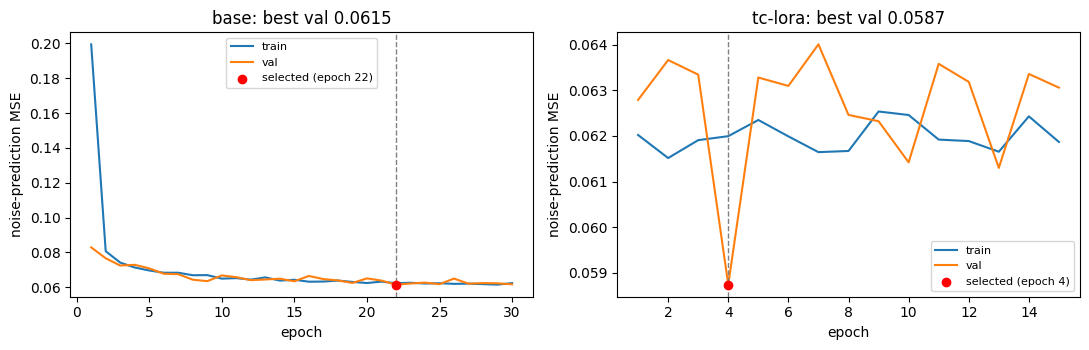

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, (name, hist) in zip(ax, [("base", base_hist), ("tc-lora", tc_hist)]):
    ep = [h["epoch"] for h in hist]
    a.plot(ep, [h["train"] for h in hist], label="train")
    a.plot(ep, [h["val"] for h in hist], label="val")
    best = min(hist, key=lambda h: h["val"])
    a.axvline(best["epoch"], ls="--", c="grey", lw=1)
    a.scatter([best["epoch"]], [best["val"]], c="red", zorder=5,
              label=f"selected (epoch {best['epoch']})")
    a.set_title(f"{name}: best val {best['val']:.4f}")
    a.set_xlabel("epoch"); a.set_ylabel("noise-prediction MSE"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Sample from both

In [11]:
N = 16
y_eval = torch.arange(N, device=DEV) % meta["n_conditions"]

base_s = ddim_sample(lambda x, t: base_frozen(x, t, y_eval), N, meta["shape"], cfg.sample_steps)
tc_s = ddim_sample(lambda x, t: tc(x, t, COND_EMB[y_eval], cond_ids=y_eval),
                   N, meta["shape"], cfg.sample_steps)
print("sampled:", tuple(base_s.shape), "| NFE per sample:", cfg.sample_steps)

sampled: (16, 3, 32, 32) | NFE per sample: 50


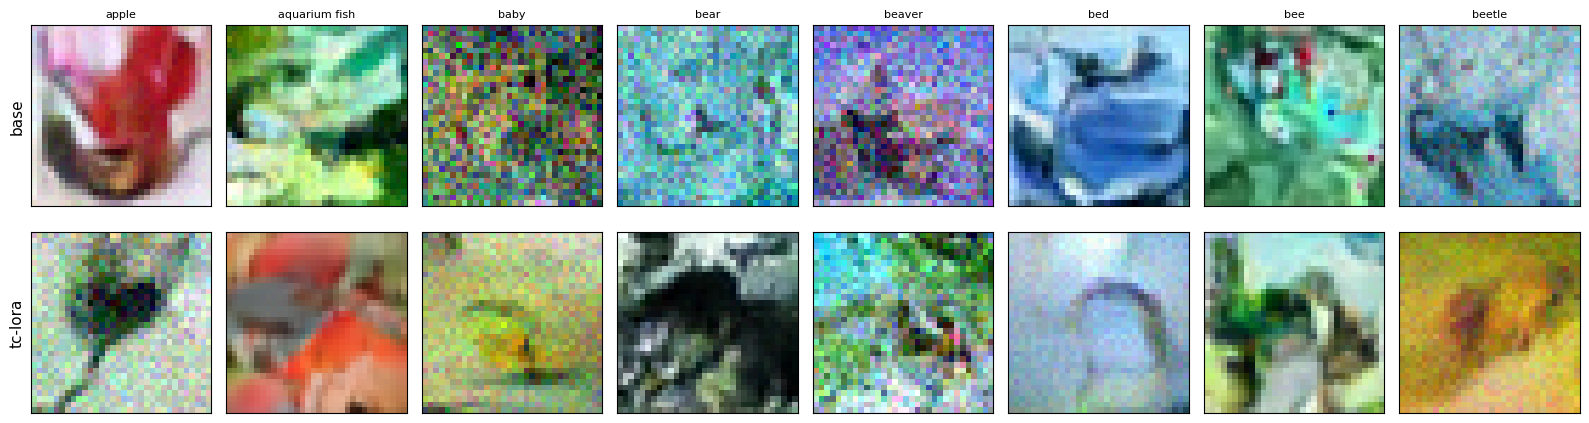

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 8, figsize=(16, 4.6))
for row, (name, s) in enumerate([("base", base_s), ("tc-lora", tc_s)]):
    for j in range(8):
        axes[row, j].imshow(((s[j].cpu() + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy())
        axes[row, j].set_xticks([]); axes[row, j].set_yticks([])
        if row == 0:
            axes[row, j].set_title(meta["cond_text"][int(y_eval[j])].replace(
                "a photo of a ", ""), fontsize=8)
    axes[row, 0].set_ylabel(name, fontsize=11)
plt.tight_layout(); plt.show()

## Denoising trajectory

The same sample at several points along the reverse process, noise on the left and the
finished image on the right. Useful for the appendix and for spotting a sampler that is
diverging rather than converging.

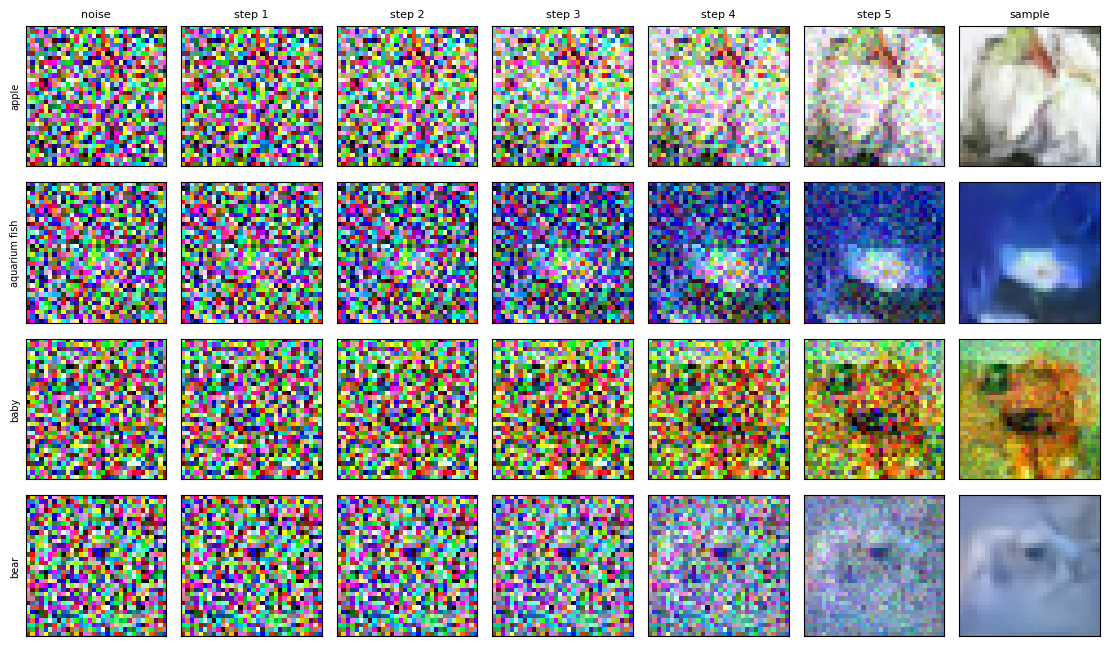

In [13]:
traj_y = y_eval[:4]
_, snaps = ddim_sample(lambda x, t: tc(x, t, COND_EMB[traj_y], cond_ids=traj_y),
                       4, meta["shape"], cfg.sample_steps, n_snapshots=6)

fig, axes = plt.subplots(4, len(snaps), figsize=(1.6 * len(snaps), 6.6))
for r in range(4):
    for c, s in enumerate(snaps):
        axes[r, c].imshow(((s[r] + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy())
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0:
            axes[r, c].set_title("noise" if c == 0 else
                                 ("sample" if c == len(snaps) - 1 else f"step {c}"),
                                 fontsize=8)
    axes[r, 0].set_ylabel(meta["cond_text"][int(traj_y[r])].replace("a photo of a ", ""),
                          fontsize=7)
plt.tight_layout(); plt.show()

## FID (optional, needs a GPU)

Section 4.1 asks for a fidelity metric on images. FID is unstable below ~10k samples, so
set `n_fid` accordingly and record the count next to the number. On an A100 this is a few
minutes; skip it while iterating.

In [20]:
n_fid = 10000          # set to 10000 for a reportable number; 0 skips this cell

FID_SCORES = {}

if n_fid:
    # torchmetrics is not preinstalled on Colab, and its FID needs torch-fidelity
    # for the Inception feature extractor.
    import importlib.util, subprocess, sys
    for pkg, mod in [("torchmetrics", "torchmetrics"), ("torch-fidelity", "torch_fidelity")]:
        if importlib.util.find_spec(mod) is None:
            print(f"installing {pkg} ...")
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

    from torchmetrics.image.fid import FrechetInceptionDistance

    def to_uint8(x):
        return ((x.clamp(-1, 1) + 1) * 127.5).round().to(torch.uint8)

    def sample_for(which, y):
        if which == "base":
            return ddim_sample(lambda x, t: base_frozen(x, t, y),
                               len(y), meta["shape"], cfg.sample_steps)
        return ddim_sample(lambda x, t: tc(x, t, COND_EMB[y], cond_ids=y),
                           len(y), meta["shape"], cfg.sample_steps)

    for which in ("base", "tclora"):
        fid = FrechetInceptionDistance(feature=2048, normalize=False).to(DEV)

        n_real = 0
        for x, _ in val_loader:
            fid.update(to_uint8(x.to(DEV)), real=True)
            n_real += len(x)

        torch.manual_seed(cfg.seed)
        for start in range(0, n_fid, 100):
            y = torch.arange(start, min(start + 100, n_fid), device=DEV) % meta["n_conditions"]
            fid.update(to_uint8(sample_for(which, y)), real=False)

        FID_SCORES[f"{which}_fid"] = float(fid.compute())
        FID_SCORES["fid_n_real"] = n_real
        FID_SCORES["fid_n_generated"] = n_fid
        print(f"{which} FID {FID_SCORES[f'{which}_fid']:.2f}   "
              f"(real {n_real}, generated {n_fid}, NFE {cfg.sample_steps})")

    if min(FID_SCORES["fid_n_real"], n_fid) < 10000:
        print()
        print("NOTE: FID is biased upward below ~10k samples. Report both counts.")
else:
    print("FID skipped (n_fid = 0)")

base FID 80.56   (real 5000, generated 10000, NFE 50)
tclora FID 79.70   (real 5000, generated 10000, NFE 50)

NOTE: FID is biased upward below ~10k samples. Report both counts.


In [21]:
from google.colab import files
files.download("base.pt")
files.download("tclora.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Manifest

In [22]:
report = {
    "method": "TC-LoRA (reimplementation of arXiv:2510.09561)",
    "modality": "images",
    "config": asdict(cfg),
    "base_best_val": min(h["val"] for h in base_hist),
    "tclora_best_val": min(h["val"] for h in tc_hist),
    "trainable_hypernetwork": tc.n_trainable(),
    "frozen_backbone": sum(p.numel() for p in base_frozen.parameters()),
    "adapted_layers": len(tc.adapted),
    "nfe": cfg.sample_steps,
    "clip_fallback": IS_FALLBACK,
    "synthetic_data": bool(meta.get("SYNTHETIC", False)),
    "device": str(DEV),
}

report.update(globals().get("FID_SCORES", {}))

print(json.dumps(report, indent=2))
with open("manifest_tclora_images.json", "w") as f:
    json.dump(report, f, indent=2)

{
  "method": "TC-LoRA (reimplementation of arXiv:2510.09561)",
  "modality": "images",
  "config": {
    "seed": 10,
    "batch_size": 64,
    "base_epochs": 30,
    "lora_epochs": 15,
    "lr_base": 0.0002,
    "lr_hyper": 0.0001,
    "K": 1000,
    "sample_steps": 50,
    "rank": 4,
    "hyper_width": 256,
    "limit": 0
  },
  "base_best_val": 0.06149011368751526,
  "tclora_best_val": 0.0587392892241478,
  "trainable_hypernetwork": 1664512,
  "frozen_backbone": 1904707,
  "adapted_layers": 12,
  "nfe": 50,
  "clip_fallback": false,
  "synthetic_data": false,
  "device": "cuda",
  "base_fid": 80.56029510498047,
  "fid_n_real": 5000,
  "fid_n_generated": 10000,
  "tclora_fid": 79.70112609863281
}


## Before reporting any of this

- [ ] FID computed separately with at least 10k samples; this notebook reports validation loss only
- [ ] `clip_fallback: false` in the manifest
- [ ] `base_epochs` and `lora_epochs` at their real values, `limit` at 0
- [ ] Three seeds, mean +/- std
- [ ] Parameter counts and NFE next to every number
- [ ] Described as a **reimplementation** of arXiv:2510.09561, not a reproduction, with the scale gap disclosed: the authors train 251M hypernetwork parameters for 3 days on 8x H100